# Learning when silence has no click: Online SDFT

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lin826/Online-SFT-Demo/blob/main/online_sdft_bandit_demo.ipynb)

A visual walkthrough of notification routing with **censored bandit feedback**. There is one stream and no train/test split: every action is scored first, and only afterward can a privileged teacher interpret its factual outcome for future learning.

In [1]:
from pathlib import Path
import csv, json, os, subprocess
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

ROOT = Path.cwd()
if not (ROOT / 'bandit_experiment.py').exists() and Path('/content').exists():
    repo = Path('/content/Online-SFT-Demo')
    if not repo.exists():
        subprocess.run(['git', 'clone', 'https://github.com/lin826/Online-SFT-Demo.git', str(repo)], check=True)
    os.chdir(repo)
    ROOT = Path.cwd()
if not (ROOT / 'bandit_experiment.py').exists():
    raise RuntimeError('Run this notebook from the repository root or open it in Colab.')
OUT = ROOT / 'outputs' / 'bandit'

## One decision, one observable world

If we choose **ARCHIVE**, no push exists. The user can later open the app organically, or we observe nothing—but a notification click is impossible.

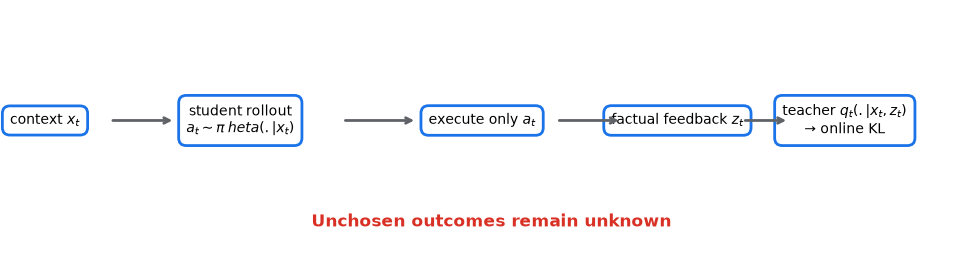

In [2]:
fig, ax = plt.subplots(figsize=(12, 3.2))
ax.axis('off')
nodes = [(0.02, 'context $x_t$'), (0.23, 'student rollout\n$a_t\sim\pi_\theta(.|x_t)$'),
         (0.49, 'execute only $a_t$'), (0.70, 'factual feedback $z_t$'),
         (0.88, 'teacher $q_t(.|x_t,z_t)$\n→ online KL')]
for x, label in nodes:
    ax.text(x, .55, label, transform=ax.transAxes, ha='center', va='center',
            bbox=dict(boxstyle='round,pad=.55', fc='white', ec='#1a73e8', lw=2))
for x1, x2 in zip([.09,.34,.57,.77], [.16,.42,.64,.82]):
    ax.annotate('', xy=(x2,.55), xytext=(x1,.55), xycoords=ax.transAxes,
                arrowprops=dict(arrowstyle='->', lw=2, color='#5f6368'))
ax.text(.5,.12,'Unchosen outcomes remain unknown',transform=ax.transAxes,ha='center',
        color='#d93025',weight='bold',fontsize=12)
plt.show()

## Reproduce the experiment

The checked-in outputs use 20 seeds. Set `RUN_EXPERIMENT=True` to regenerate all 24,000 decisions and figures.

In [3]:
RUN_EXPERIMENT = False
if RUN_EXPERIMENT:
    from bandit_experiment import main
    main(seeds=20)

## Five methods, one learning signal

- **Base:** frozen generic policy.
- **ICL:** recent hard teacher rollouts in context.
- **RAG:** hard rollouts from similar past contexts.
- **Online-SFT:** one sampled teacher rollout becomes a hard target.
- **Online-SDFT:** learns the complete teacher distribution.

No method learns from the evaluation oracle.

In [4]:
summary = json.loads((OUT / 'summary.json').read_text())
methods = summary['config']['methods']
print(f"{summary['config']['seeds']} seeds × {summary['config']['stream_length']} decisions")
print(f"{'Method':<14} {'Accuracy':>12} {'95% CI':>10} {'Regret':>12} {'95% CI':>10}")
for method in methods:
    row = summary['summary'][method]
    a, r = row['online_accuracy'], row['cum_regret']
    print(f"{method:<14} {100*a['mean']:>11.2f}% {100*a['ci95']:>9.2f} {r['mean']:>12.2f} {r['ci95']:>10.2f}")

20 seeds × 240 decisions
Method             Accuracy     95% CI       Regret     95% CI
Base                 52.17%      1.23        71.17       2.93
ICL                  45.75%      1.05        78.38       3.39
RAG                  53.15%      1.62        56.60       4.39
Online-SFT           61.79%      2.51        40.17       4.51
Online-SDFT          74.77%      1.24        18.65       1.28


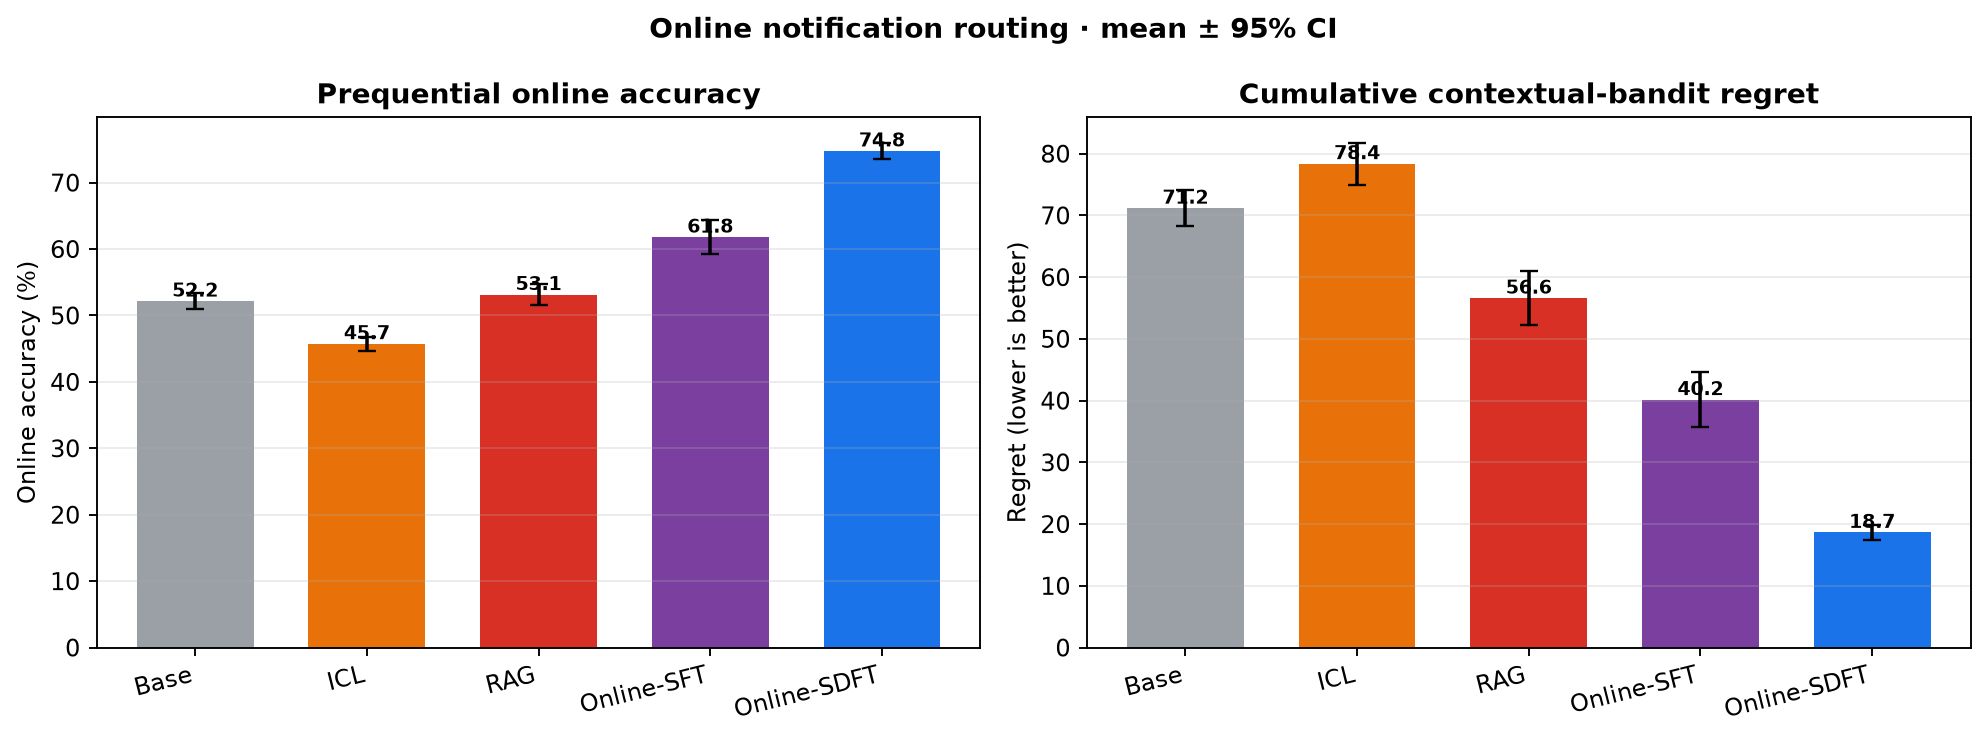

In [5]:
display(Image(filename=str(ROOT / 'figures' / 'bandit_accuracy.png'), width=950))

## Watch adaptation and regret accumulate

Dashed boundaries mark the weekday → on-call → off-hours shifts. Shaded regions are 95% confidence intervals.

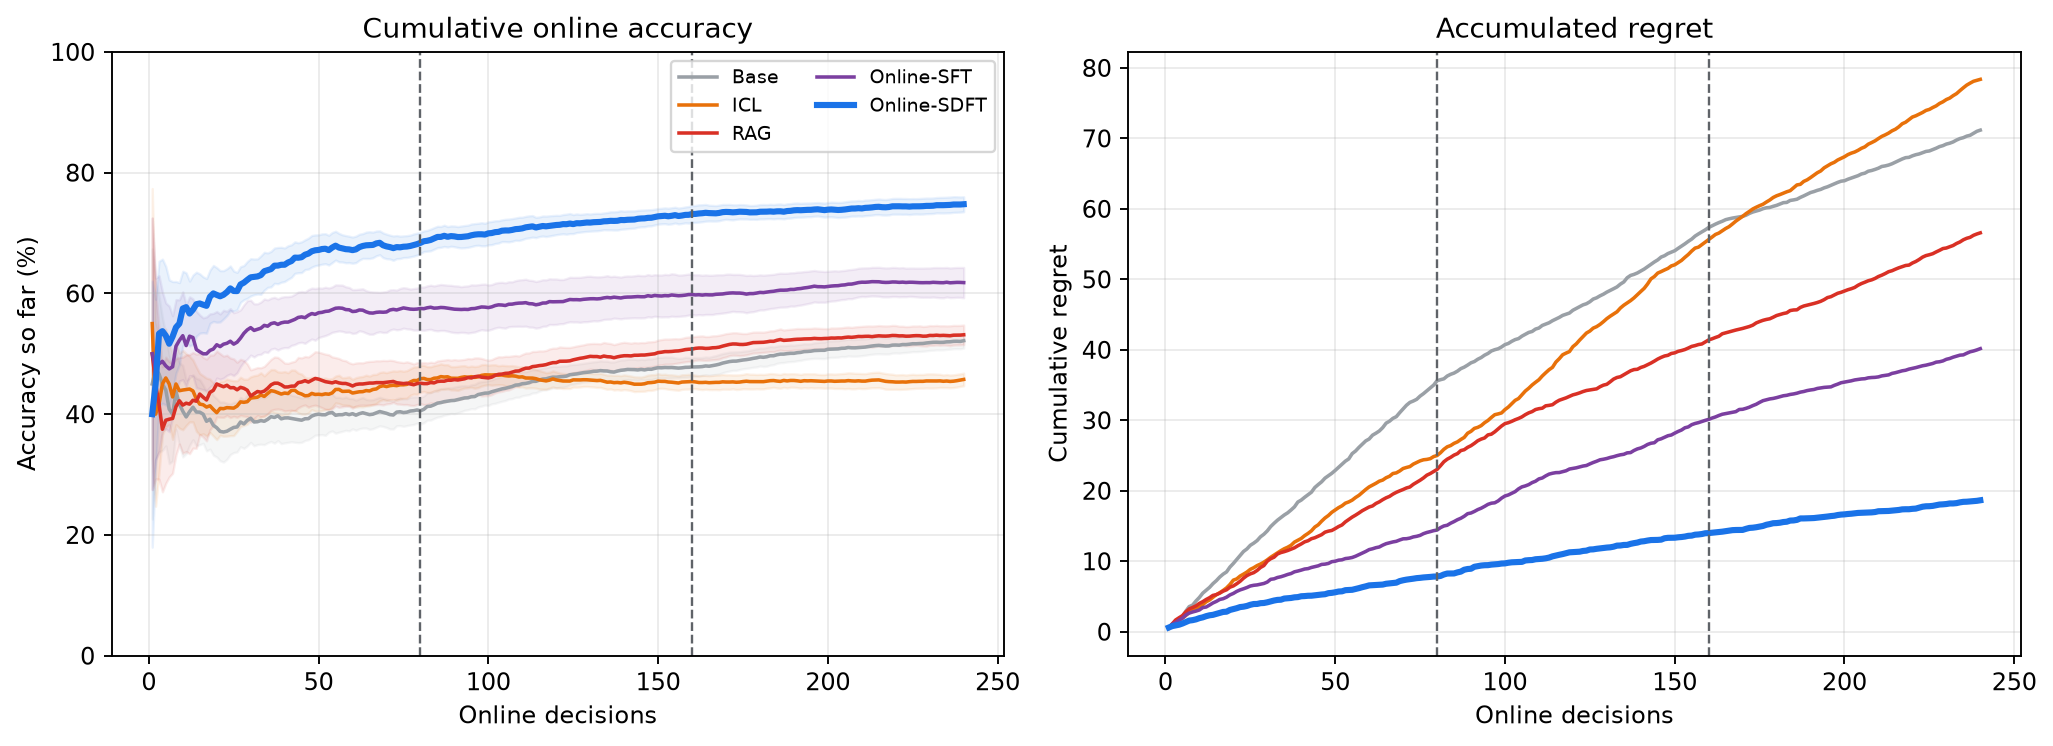

In [6]:
display(Image(filename=str(ROOT / 'figures' / 'bandit_learning_curves.png'), width=1000))

## Audit the counterfactual boundary

The raw rollout log lets us verify that archived notifications never generate push or digest clicks.

In [7]:
rollouts = [json.loads(line) for line in (OUT / 'rollouts.jsonl').open()]
archived = [r for r in rollouts if r['action'] == 'ARCHIVE']
archive_outcomes = Counter(r['feedback']['outcome'] for r in archived)
display(Markdown(f'**{len(archived):,} archived decisions:** `{dict(archive_outcomes)}`'))
assert set(archive_outcomes) <= {'ORGANIC_INBOX_OPEN', 'NO_OBSERVATION'}

**5,142 archived decisions:** `{'NO_OBSERVATION': 4536, 'ORGANIC_INBOX_OPEN': 606}`

## Where soft rollouts help

These examples occur after at least one complete online regime. SDFT is correct while every comparison method chooses another route. The outcome shown for each method is factual for its own chosen action.

In [8]:
examples = json.loads((OUT / 'qualitative_examples.json').read_text())
for ex in examples[:4]:
    display(Markdown(f"### Step {ex['t']} · {ex['regime']} · {ex['category']}  \nScoring-best route: **{ex['oracle_action_scoring_only']}**"))
    for method, row in ex['methods'].items():
        marker = '✅' if row['action'] == ex['oracle_action_scoring_only'] else '·'
        print(f"{marker} {method:<13} {row['action']:<10} → {row['feedback']['outcome']}")

### Step 87 · on-call · receipt  
Scoring-best route: **ARCHIVE**

· Base          INTERRUPT  → DISMISSED_PUSH
· ICL           LATER      → OPENED_DIGEST
· RAG           INTERRUPT  → DISMISSED_PUSH
· Online-SFT    LATER      → IGNORED_DIGEST
✅ Online-SDFT   ARCHIVE    → NO_OBSERVATION


### Step 96 · on-call · receipt  
Scoring-best route: **ARCHIVE**

· Base          INTERRUPT  → OPENED_PUSH
· ICL           INTERRUPT  → OPENED_PUSH
· RAG           LATER      → IGNORED_DIGEST
· Online-SFT    LATER      → IGNORED_DIGEST
✅ Online-SDFT   ARCHIVE    → NO_OBSERVATION


### Step 150 · on-call · receipt  
Scoring-best route: **ARCHIVE**

· Base          INTERRUPT  → IGNORED_PUSH
· ICL           INTERRUPT  → IGNORED_PUSH
· RAG           LATER      → OPENED_DIGEST
· Online-SFT    LATER      → IGNORED_DIGEST
✅ Online-SDFT   ARCHIVE    → NO_OBSERVATION


### Step 162 · off-hours · social  
Scoring-best route: **LATER**

· Base          INTERRUPT  → OPENED_PUSH
· ICL           INTERRUPT  → DISMISSED_PUSH
· RAG           INTERRUPT  → DISMISSED_PUSH
· Online-SFT    INTERRUPT  → OPENED_PUSH
✅ Online-SDFT   LATER      → IGNORED_DIGEST


## Takeaway

SFT receives one noisy sampled action from the teacher. SDFT receives the teacher's relative preference over all three actions. On the one prequential stream, retaining that uncertainty improves sample efficiency: **74.8% vs 61.8% online accuracy**, with **18.7 vs 40.2** cumulative regret.